<a href="https://colab.research.google.com/github/nesredingebeyehu15-dot/My-AI-Engineering-Journey/blob/main/Day_09_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. RAW DATA LOADED ---


,Cust_ID,Name,Region
0,101,Abebe,Addis
1,102,Sara,Jimma
2,103,Tola,Addis


,Transaction_ID,Cust_ID,Amount
0,1,101,$500
1,2,101,$200
2,3,102,$1000



--- 2. DATA CLEANED ---


,Cust_ID,Name,Region
0,101,Abebe,Addis
1,102,Sara,Jimma
2,103,Tola,Addis


...


--- 3. MERGED DATASET ---


,Transaction_ID,Cust_ID,Amount,Name,Region
0,1,101,500.0,Abebe,Addis
1,2,101,200.0,Abebe,Addis
2,3,102,1000.0,Sara,Jimma
3,4,103,50.0,Tola,Addis
4,5,101,300.0,Abebe,Addis



--- 4. VIP CUSTOMER RANKING ---


,Amount
Name,
Abebe,1000.0
Sara,1000.0
Tola,50.0


/tmp/ipython-input-517796637.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vip_report.index, y=vip_report.values, palette='viridis')


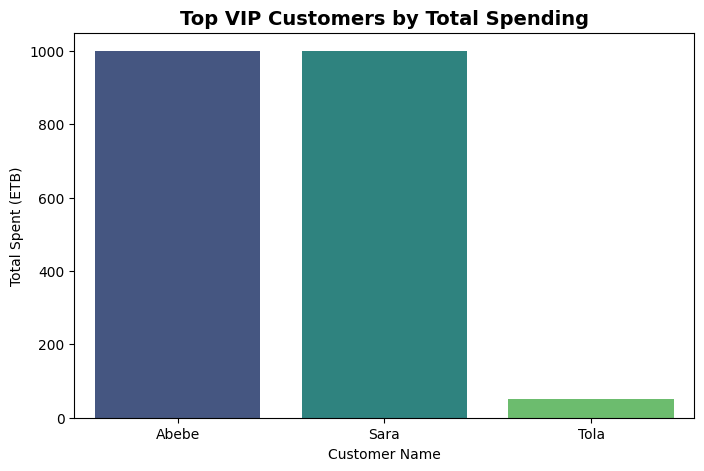

In [11]:
# DAY 9 ACADEMY: END-TO-END DATA PIPELINE
# Author: Nesredin Gebeyehu
# Objective: Integrate Cleaning, Merging, and Analysis to find VIP Customers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA INGESTION (RAW DATA)
# ==========================================
customers = pd.DataFrame({
    'Cust_ID': [101, 102, 103, 104, 105],
    'Name': ['  Abebe ', 'Sara', 'Tola', 'Marta', 'Zewdu'],
    'Region': ['Addis', 'Jimma', 'Addis', 'Bahir Dar', 'Jimma']
})

sales = pd.DataFrame({
    'Transaction_ID': [1, 2, 3, 4, 5, 6],
    'Cust_ID': [101, 101, 102, 103, 101, 999], # 999 is unknown
    'Amount': ['$500', '$200', '$1000', '$50', '$300', '$100']
})

print("--- 1. RAW DATA LOADED ---")
display(customers.head(3))
display(sales.head(3))

# ==========================================
# 2. DATA CLEANING (THE JANITOR)
# ==========================================
# Clean Names (Strip spaces & Title case)
customers['Name'] = customers['Name'].str.strip().str.title()

# Clean Amounts (Remove $ & Convert to Float)
sales['Amount'] = sales['Amount'].str.replace('$', '').astype(float)

print("\n--- 2. DATA CLEANED ---")
display(customers.head(3))
display(sales.dtypes)

# ==========================================
# 3. MERGING (THE BRIDGE)
# ==========================================
# Inner Join: We only want sales from registered customers
full_data = pd.merge(sales, customers, on='Cust_ID', how='inner')

print("\n--- 3. MERGED DATASET ---")
display(full_data)

# ==========================================
# 4. ANALYSIS (THE INSIGHT)
# ==========================================
# Who spent the most money?
vip_report = full_data.groupby('Name')['Amount'].sum().sort_values(ascending=False)

print("\n--- 4. VIP CUSTOMER RANKING ---")
display(vip_report)

# ==========================================
# 5. VISUALIZATION (THE DISPLAY)
# ==========================================
plt.figure(figsize=(8, 5), facecolor='white')
sns.barplot(x=vip_report.index, y=vip_report.values, palette='viridis')

plt.title('Top VIP Customers by Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Customer Name')
plt.ylabel('Total Spent (ETB)')
plt.show()